In [6]:
# ==========================================
# 1. IMPORTAR LIBRERÍAS
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Configuración visual
sns.set_theme(style="whitegrid")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [7]:
# ==========================================
# 2. CARGAR DATOS
# ==========================================

from google.colab import files

uploaded = files.upload()

Saving mis_partidas_lol.csv to mis_partidas_lol (1).csv


In [8]:
df = pd.read_csv("mis_partidas_lol.csv")

print("Datos cargados correctamente.")
print("Número de partidas:", len(df))

Datos cargados correctamente.
Número de partidas: 52


In [9]:
display(df.head())

,match_id,fecha_hora,resultado,campeon,rol,kills,muertes,asistencias,kda,cs,...,oro_min,dano_campeones,dano_min,dano_recibido,vision_score,wards_colocados,wards_destruidos,control_wards,kill_participation,duracion_min
0,LA1_1746975761,2026-09-07 06:24:27.293,Derrota,Maokai,UTILITY,0,5,3,0.60,26,...,254.92,7144,461.40,10990,24,12,1,0,75.00,15.48
1,LA1_1746972235,2026-09-07 05:48:52.931,Victoria,Maokai,UTILITY,3,6,12,2.50,41,...,318.72,12545,434.08,19060,73,23,10,0,34.09,28.90
2,LA1_1746930688,2026-09-07 03:41:18.391,Derrota,Seraphine,UTILITY,3,9,10,1.44,76,...,323.47,17571,618.33,23719,64,26,5,0,50.00,28.42
3,LA1_1746915437,2026-09-07 03:00:52.799,Derrota,Pantheon,UTILITY,2,12,13,1.25,66,...,307.51,17124,533.74,28464,76,28,6,0,65.22,32.08
4,LA1_1746712100,2026-09-06 07:36:00.243,Victoria,Pantheon,UTILITY,7,5,8,3.00,51,...,414.13,12910,541.68,15274,57,26,4,0,41.67,23.83


In [10]:
# ==========================================
# 3. INFORMACIÓN DEL DATAFRAME
# ==========================================

print("Filas y columnas:")
print(df.shape)

print("\nColumnas:")
print(df.columns.tolist())

print("\nInformación:")

Filas y columnas:
(52, 22)

Columnas:
['match_id', 'fecha_hora', 'resultado', 'campeon', 'rol', 'kills', 'muertes', 'asistencias', 'kda', 'cs', 'cs_min', 'oro', 'oro_min', 'dano_campeones', 'dano_min', 'dano_recibido', 'vision_score', 'wards_colocados', 'wards_destruidos', 'control_wards', 'kill_participation', 'duracion_min']

Información:


In [11]:
df.describe()

,kills,muertes,asistencias,kda,cs,cs_min,oro,oro_min,dano_campeones,dano_min,dano_recibido,vision_score,wards_colocados,wards_destruidos,control_wards,kill_participation,duracion_min
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.00000,52.000000,52.000000,52.000000,52.000000,52.0,52.000000,52.000000
mean,3.403846,5.192308,12.557692,4.460962,97.461538,3.058269,10658.865385,342.575577,16184.134615,504.15500,20066.615385,65.750000,27.461538,6.788462,0.0,50.590962,30.923077
std,2.830226,2.779748,7.110924,5.052803,89.639247,2.580382,3236.835110,55.791663,10970.376146,263.72025,8567.874109,31.834668,11.867672,4.239573,0.0,13.675013,7.100822
min,0.000000,0.000000,2.000000,0.600000,15.000000,0.550000,3947.000000,251.760000,4464.000000,181.49000,5243.000000,19.000000,8.000000,0.000000,0.0,20.000000,15.420000
25%,1.000000,3.000000,6.000000,2.200000,38.500000,1.400000,9040.500000,302.757500,9242.000000,315.32500,13763.000000,35.750000,17.000000,3.750000,0.0,39.905000,27.832500
50%,3.000000,5.000000,11.500000,3.000000,55.500000,1.725000,10350.000000,337.770000,12646.000000,395.28500,19309.000000,70.000000,27.000000,6.000000,0.0,50.580000,30.385000
75%,5.000000,6.250000,18.000000,4.625000,115.250000,3.557500,12491.750000,387.850000,19162.500000,617.51250,25399.750000,91.250000,36.000000,10.000000,0.0,61.540000,34.047500
max,11.000000,12.000000,30.000000,26.000000,404.000000,8.870000,22308.000000,466.660000,52383.000000,1278.98000,41591.000000,149.000000,56.000000,15.000000,0.0,75.760000,49.930000


In [12]:
# ==========================================
# 4. DATOS FALTANTES
# ==========================================

faltantes = df.isnull().sum()

print(faltantes)

match_id              0
fecha_hora            0
resultado             0
campeon               0
rol                   0
kills                 0
muertes               0
asistencias           0
kda                   0
cs                    0
cs_min                0
oro                   0
oro_min               0
dano_campeones        0
dano_min              0
dano_recibido         0
vision_score          0
wards_colocados       0
wards_destruidos      0
control_wards         0
kill_participation    0
duracion_min          0
dtype: int64


In [13]:
# ==========================================
# 5. PREPARAR FECHA
# ==========================================

df["fecha_hora"] = pd.to_datetime(df["fecha_hora"])

df["fecha"] = df["fecha_hora"].dt.date
df["hora"] = df["fecha_hora"].dt.hour
df["dia_semana"] = df["fecha_hora"].dt.day_name()

display(df[[
    "fecha_hora",
    "fecha",
    "hora",
    "dia_semana"
]].head())

,fecha_hora,fecha,hora,dia_semana
0,2026-09-07 06:24:27.293,2026-09-07,6,Monday
1,2026-09-07 05:48:52.931,2026-09-07,5,Monday
2,2026-09-07 03:41:18.391,2026-09-07,3,Monday
3,2026-09-07 03:00:52.799,2026-09-07,3,Monday
4,2026-09-06 07:36:00.243,2026-09-06,7,Sunday


In [14]:
dias = {
    "Monday": "Lunes",
    "Tuesday": "Martes",
    "Wednesday": "Miércoles",
    "Thursday": "Jueves",
    "Friday": "Viernes",
    "Saturday": "Sábado",
    "Sunday": "Domingo"
}

df["dia_semana"] = df["dia_semana"].map(dias)

In [15]:
partidas = len(df)

print("Partidas jugadas:", partidas)

Partidas jugadas: 52


In [16]:
victorias = (df["resultado"] == "Victoria").sum()

print("Victorias:", victorias)

Victorias: 30


In [17]:
derrotas = (df["resultado"] == "Derrota").sum()

print("Derrotas:", derrotas)

Derrotas: 22


In [18]:
winrate = victorias / partidas * 100

print(f"Win Rate: {winrate:.2f}%")

Win Rate: 57.69%


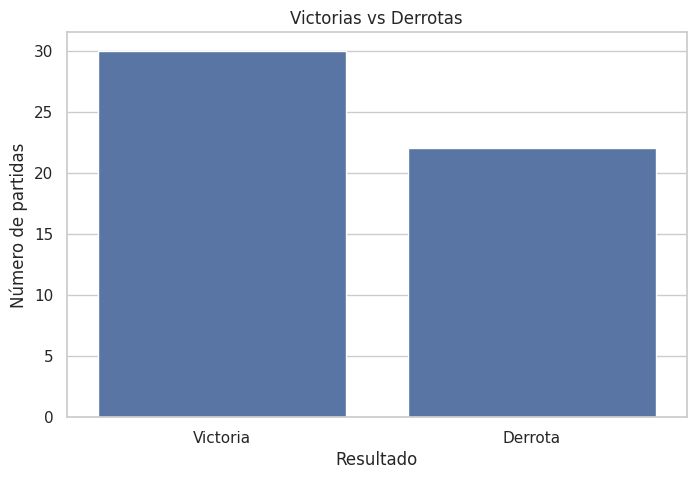

In [19]:
# ==========================================
# VICTORIAS VS DERROTAS
# ==========================================

resultado = df["resultado"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=resultado.index,
    y=resultado.values
)

plt.title("Victorias vs Derrotas")
plt.xlabel("Resultado")
plt.ylabel("Número de partidas")

plt.show()

In [20]:
# ==========================================
# KDA
# ==========================================

df["kda_calculado"] = (
    df["kills"] + df["asistencias"]
) / df["muertes"].replace(0, 1)

In [21]:
kda_promedio = df["kda_calculado"].mean()

print(f"KDA promedio: {kda_promedio:.2f}")

KDA promedio: 4.46


In [22]:
print("Kills promedio:", df["kills"].mean())
print("Muertes promedio:", df["muertes"].mean())
print("Asistencias promedio:", df["asistencias"].mean())

Kills promedio: 3.4038461538461537
Muertes promedio: 5.1923076923076925
Asistencias promedio: 12.557692307692308


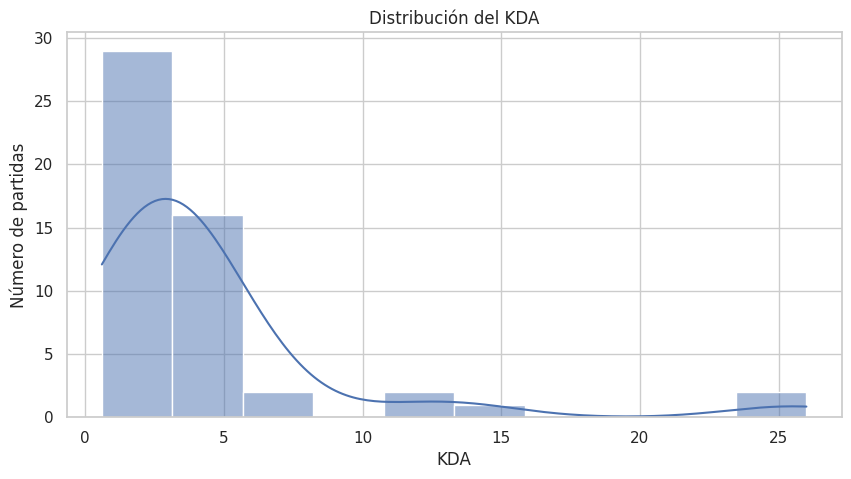

In [23]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["kda_calculado"],
    bins=10,
    kde=True
)

plt.title("Distribución del KDA")
plt.xlabel("KDA")
plt.ylabel("Número de partidas")

plt.show()

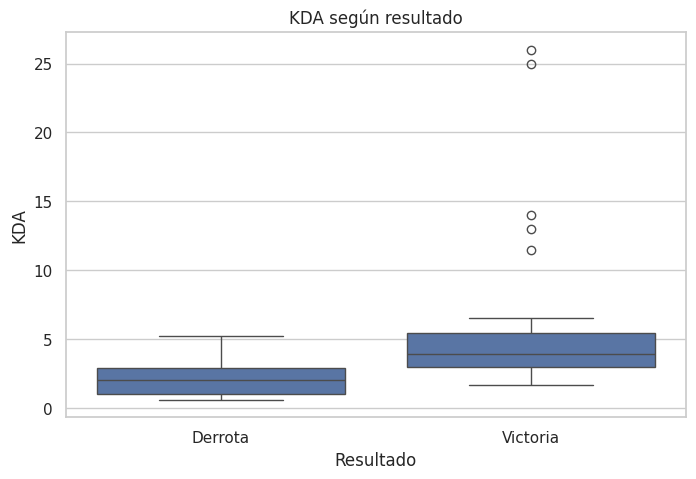

In [24]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="resultado",
    y="kda_calculado"
)

plt.title("KDA según resultado")
plt.xlabel("Resultado")
plt.ylabel("KDA")

plt.show()

In [25]:
campeones = df["campeon"].value_counts()

print(campeones)

campeon
Malzahar     10
Nami          9
Pantheon      7
Nautilus      7
Galio         5
Neeko         4
Maokai        2
Seraphine     2
Leona         2
Annie         2
Bard          1
Rakan         1
Name: count, dtype: int64


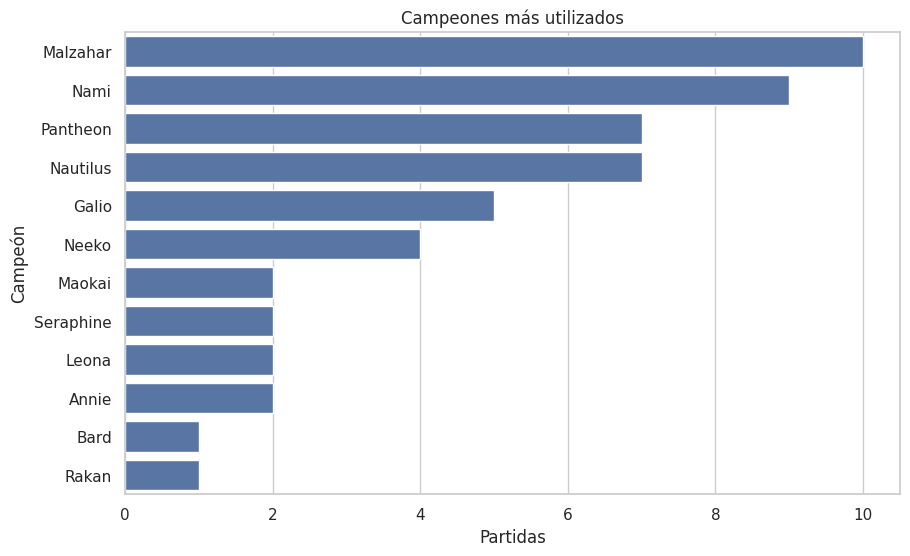

In [26]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=campeones.values,
    y=campeones.index
)

plt.title("Campeones más utilizados")
plt.xlabel("Partidas")
plt.ylabel("Campeón")

plt.show()

In [27]:
winrate_campeon = (
    df.groupby("campeon")["resultado"]
    .apply(lambda x: (x == "Victoria").mean() * 100)
    .sort_values(ascending=False)
)

print(winrate_campeon)

campeon
Leona        100.000000
Rakan        100.000000
Nami          77.777778
Pantheon      71.428571
Galio         60.000000
Nautilus      57.142857
Malzahar      50.000000
Maokai        50.000000
Seraphine     50.000000
Neeko         25.000000
Annie          0.000000
Bard           0.000000
Name: resultado, dtype: float64


In [28]:
partidas_campeon = df["campeon"].value_counts()

campeones_validos = partidas_campeon[partidas_campeon >= 3].index

winrate_campeon_filtrado = winrate_campeon[
    winrate_campeon.index.isin(campeones_validos)
]

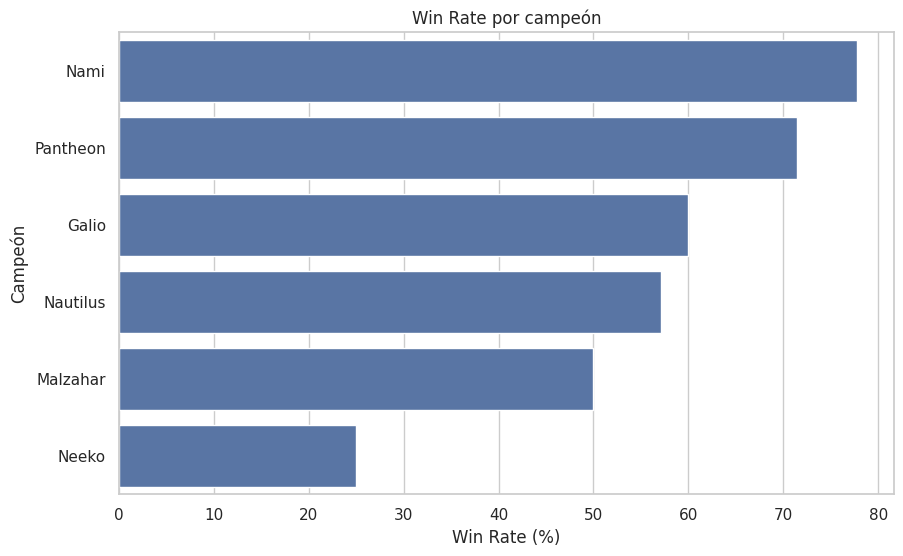

In [29]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=winrate_campeon_filtrado.values,
    y=winrate_campeon_filtrado.index
)

plt.title("Win Rate por campeón")
plt.xlabel("Win Rate (%)")
plt.ylabel("Campeón")

plt.show()

In [30]:
kda_campeon = (
    df.groupby("campeon")["kda_calculado"]
    .mean()
    .sort_values(ascending=False)
)

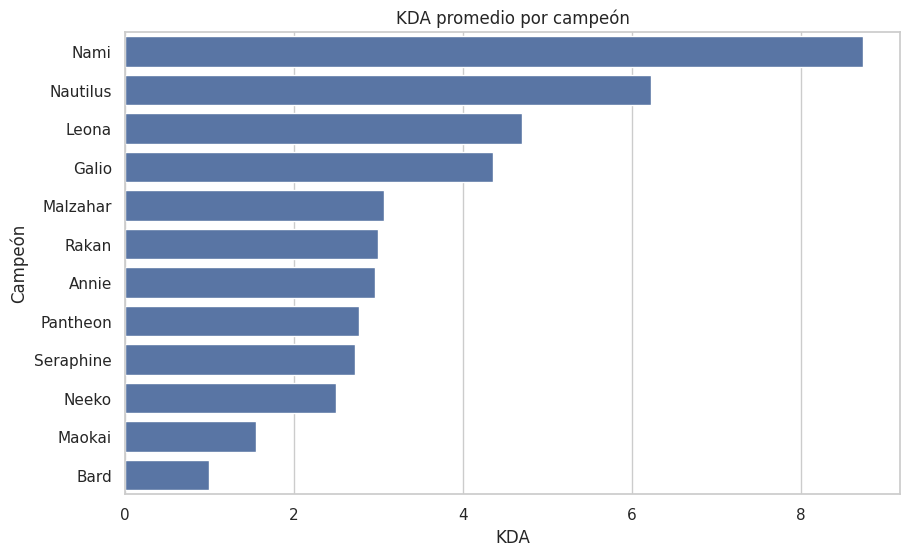

In [31]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=kda_campeon.values,
    y=kda_campeon.index
)

plt.title("KDA promedio por campeón")
plt.xlabel("KDA")
plt.ylabel("Campeón")

plt.show()

In [32]:
roles = df["rol"].value_counts()

print(roles)

rol
UTILITY    39
MIDDLE     13
Name: count, dtype: int64


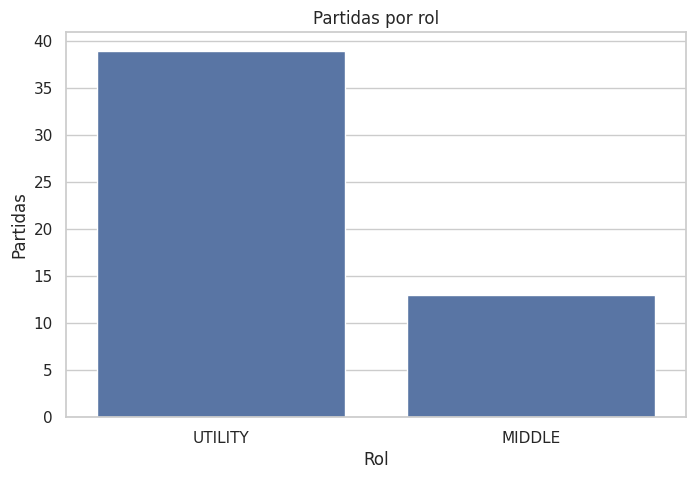

In [33]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=roles.index,
    y=roles.values
)

plt.title("Partidas por rol")
plt.xlabel("Rol")
plt.ylabel("Partidas")

plt.show()

In [34]:
winrate_rol = (
    df.groupby("rol")["resultado"]
    .apply(lambda x: (x == "Victoria").mean() * 100)
    .sort_values(ascending=False)
)

print(winrate_rol)

rol
UTILITY    64.102564
MIDDLE     38.461538
Name: resultado, dtype: float64


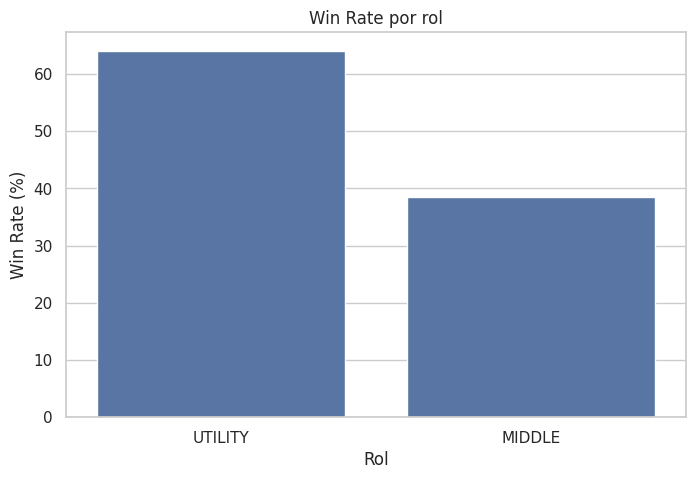

In [35]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=winrate_rol.index,
    y=winrate_rol.values
)

plt.title("Win Rate por rol")
plt.xlabel("Rol")
plt.ylabel("Win Rate (%)")

plt.show()

In [36]:
print("CS/min promedio:", df["cs_min"].mean())

CS/min promedio: 3.058269230769231


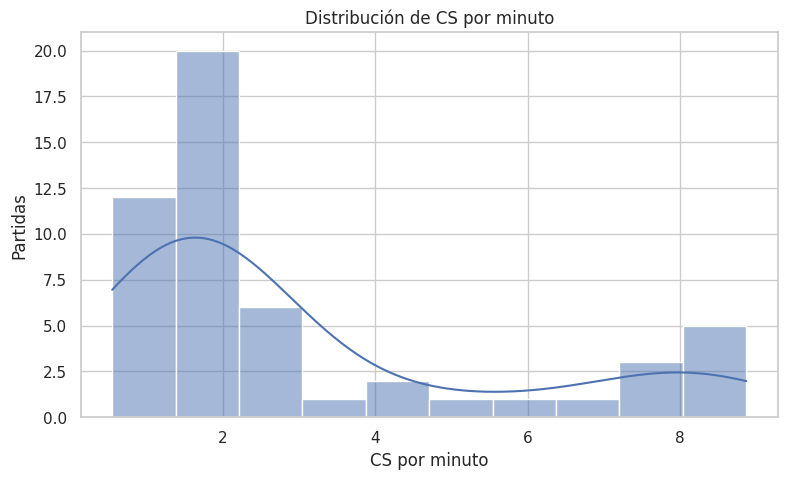

In [37]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df["cs_min"],
    bins=10,
    kde=True
)

plt.title("Distribución de CS por minuto")
plt.xlabel("CS por minuto")
plt.ylabel("Partidas")

plt.show()

In [38]:
cs_campeon = (
    df.groupby("campeon")["cs_min"]
    .mean()
    .sort_values(ascending=False)
)

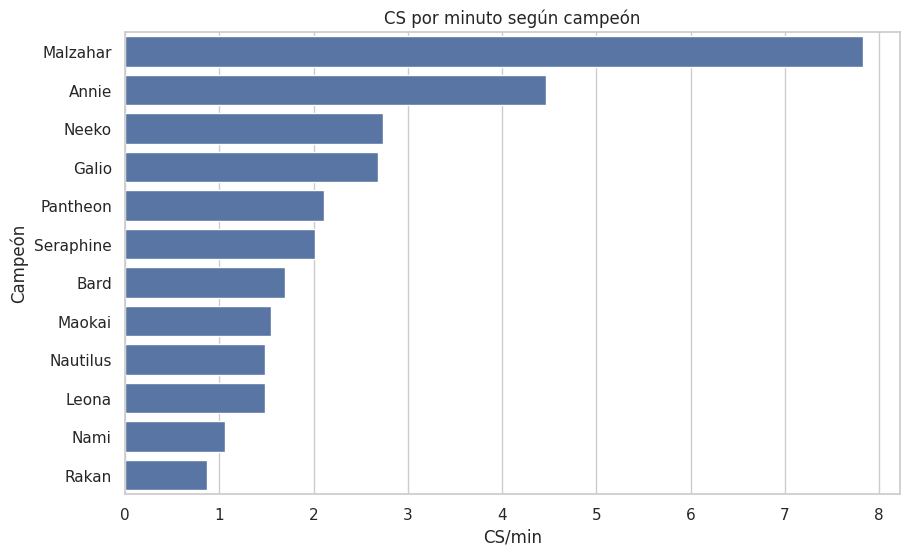

In [39]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=cs_campeon.values,
    y=cs_campeon.index
)

plt.title("CS por minuto según campeón")
plt.xlabel("CS/min")
plt.ylabel("Campeón")

plt.show()

In [40]:
print(
    f"Oro/min promedio: {df['oro_min'].mean():.2f}"
)

Oro/min promedio: 342.58


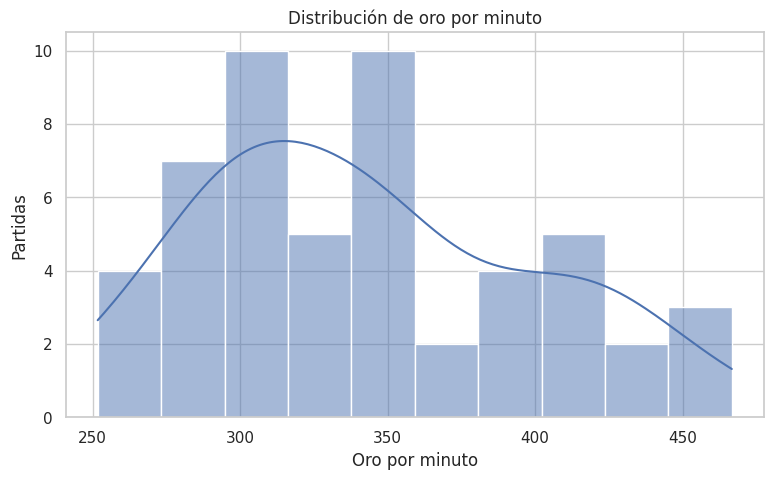

In [41]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df["oro_min"],
    bins=10,
    kde=True
)

plt.title("Distribución de oro por minuto")
plt.xlabel("Oro por minuto")
plt.ylabel("Partidas")

plt.show()

In [42]:
print(
    f"Daño promedio: {df['dano_campeones'].mean():.0f}"
)

Daño promedio: 16184


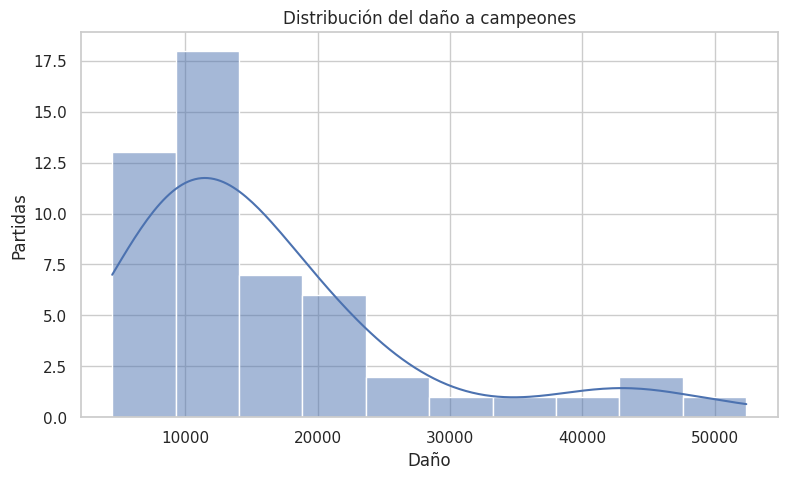

In [43]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df["dano_campeones"],
    bins=10,
    kde=True
)

plt.title("Distribución del daño a campeones")
plt.xlabel("Daño")
plt.ylabel("Partidas")

plt.show()

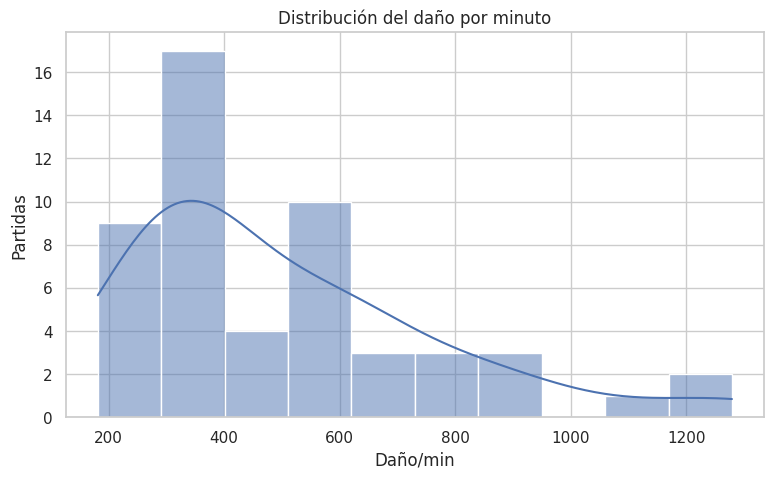

In [44]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df["dano_min"],
    bins=10,
    kde=True
)

plt.title("Distribución del daño por minuto")
plt.xlabel("Daño/min")
plt.ylabel("Partidas")

plt.show()

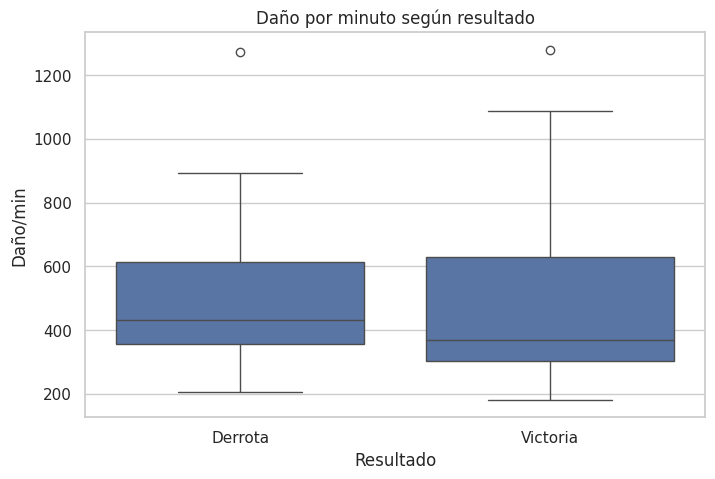

In [45]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="resultado",
    y="dano_min"
)

plt.title("Daño por minuto según resultado")
plt.xlabel("Resultado")
plt.ylabel("Daño/min")

plt.show()

In [46]:
print(
    f"Kill Participation promedio: "
    f"{df['kill_participation'].mean():.2f}%"
)

Kill Participation promedio: 50.59%


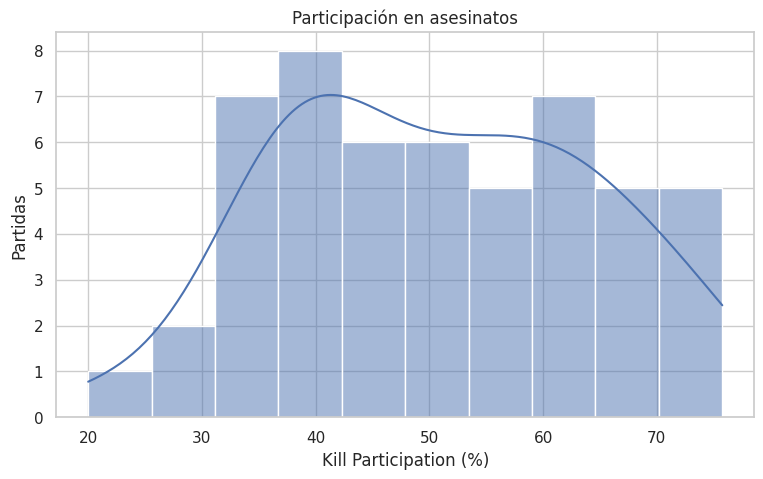

In [47]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df["kill_participation"],
    bins=10,
    kde=True
)

plt.title("Participación en asesinatos")
plt.xlabel("Kill Participation (%)")
plt.ylabel("Partidas")

plt.show()

In [48]:
kp_rol = (
    df.groupby("rol")["kill_participation"]
    .mean()
    .sort_values(ascending=False)
)

print(kp_rol)

rol
UTILITY    52.746410
MIDDLE     44.124615
Name: kill_participation, dtype: float64


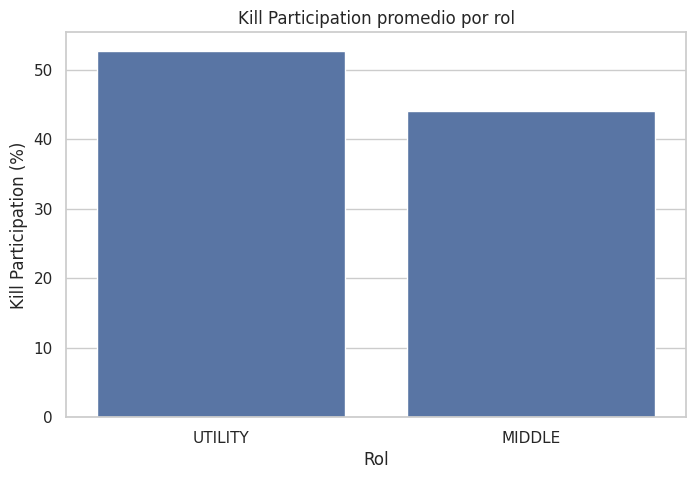

In [49]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=kp_rol.index,
    y=kp_rol.values
)

plt.title("Kill Participation promedio por rol")
plt.xlabel("Rol")
plt.ylabel("Kill Participation (%)")

plt.show()

In [50]:
print(
    "Vision Score promedio:",
    df["vision_score"].mean()
)

Vision Score promedio: 65.75


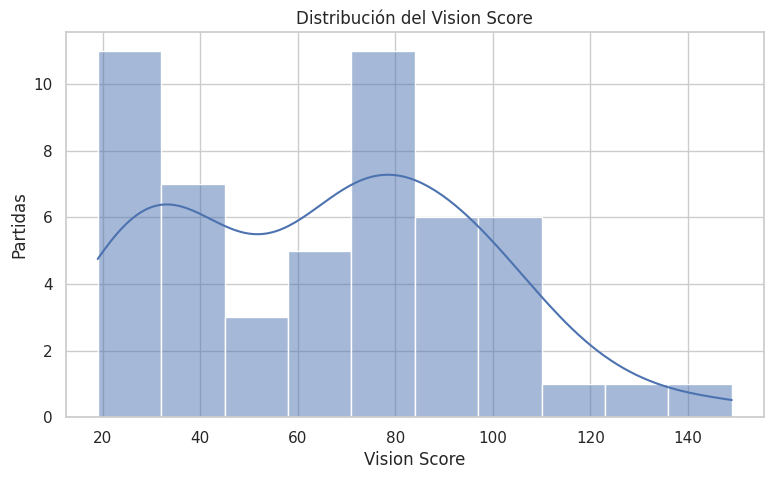

In [51]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df["vision_score"],
    bins=10,
    kde=True
)

plt.title("Distribución del Vision Score")
plt.xlabel("Vision Score")
plt.ylabel("Partidas")

plt.show()

In [52]:
print(
    f"Duración promedio: "
    f"{df['duracion_min'].mean():.2f} minutos"
)

Duración promedio: 30.92 minutos


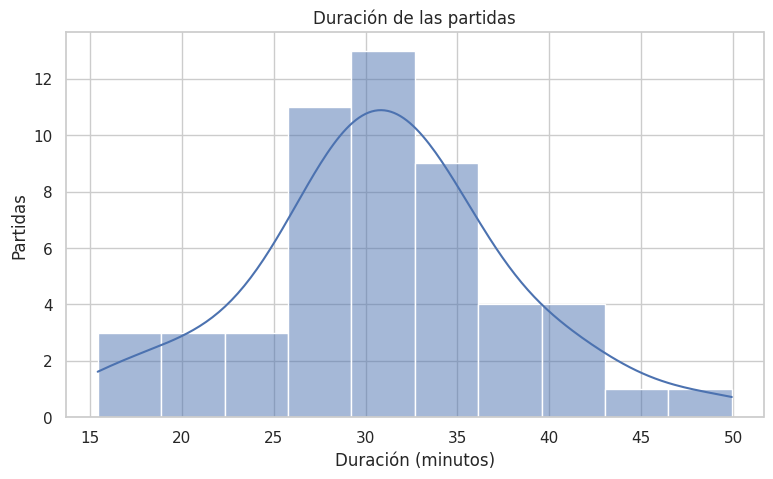

In [53]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df["duracion_min"],
    bins=10,
    kde=True
)

plt.title("Duración de las partidas")
plt.xlabel("Duración (minutos)")
plt.ylabel("Partidas")

plt.show()

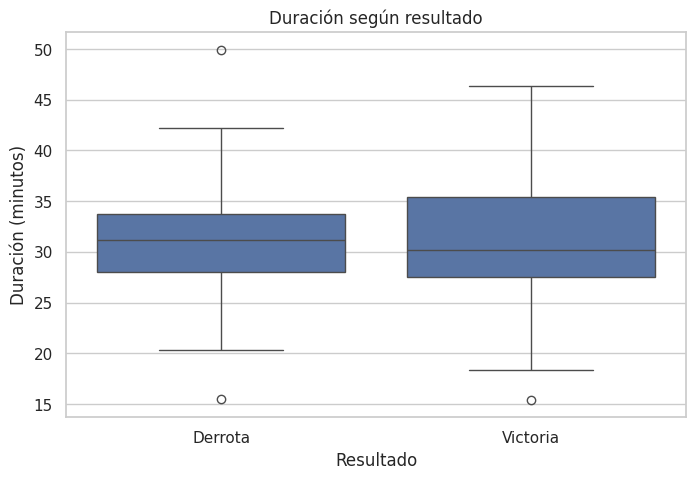

In [54]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="resultado",
    y="duracion_min"
)

plt.title("Duración según resultado")
plt.xlabel("Resultado")
plt.ylabel("Duración (minutos)")

plt.show()

In [55]:
orden_dias = [
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo"
]

actividad_dia = (
    df["dia_semana"]
    .value_counts()
    .reindex(orden_dias)
)

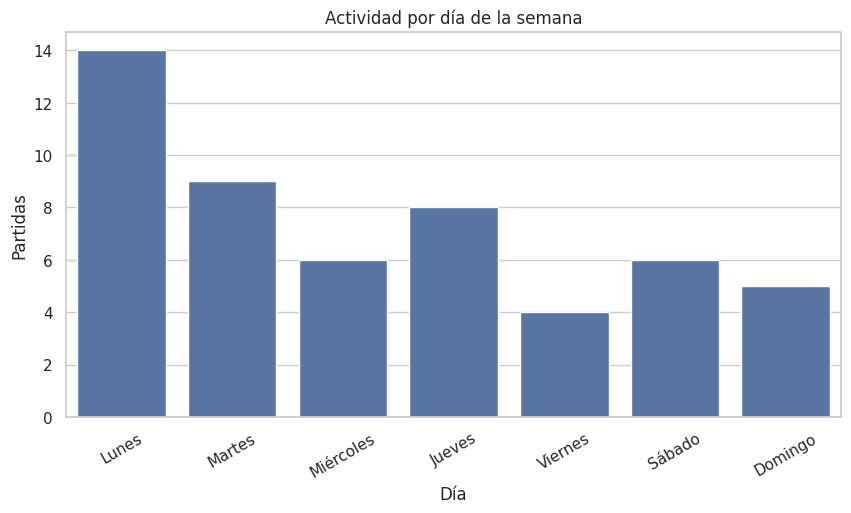

In [56]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=actividad_dia.index,
    y=actividad_dia.values
)

plt.title("Actividad por día de la semana")
plt.xlabel("Día")
plt.ylabel("Partidas")

plt.xticks(rotation=30)

plt.show()

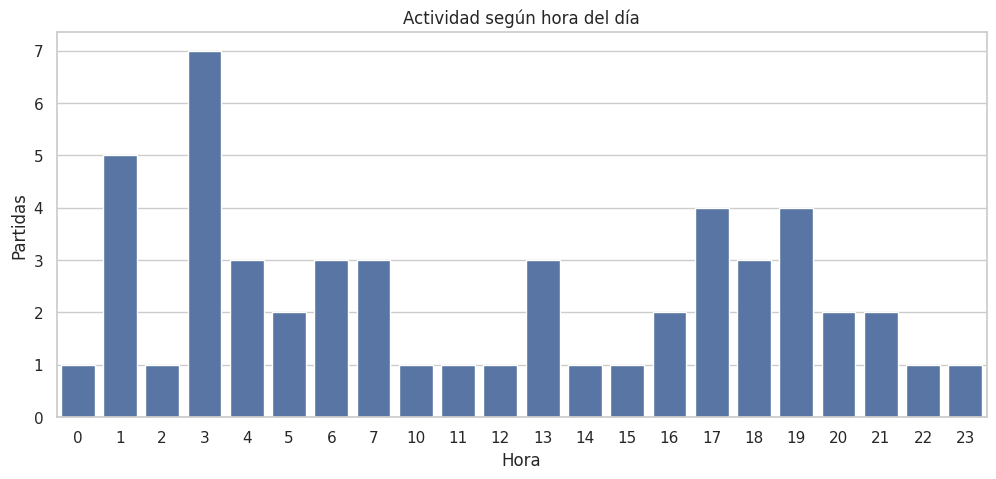

In [57]:
actividad_hora = df["hora"].value_counts().sort_index()

plt.figure(figsize=(12, 5))

sns.barplot(
    x=actividad_hora.index,
    y=actividad_hora.values
)

plt.title("Actividad según hora del día")
plt.xlabel("Hora")
plt.ylabel("Partidas")

plt.show()

In [58]:
tabla_hora_dia = pd.crosstab(
    df["dia_semana"],
    df["hora"]
)

tabla_hora_dia = tabla_hora_dia.reindex(orden_dias)

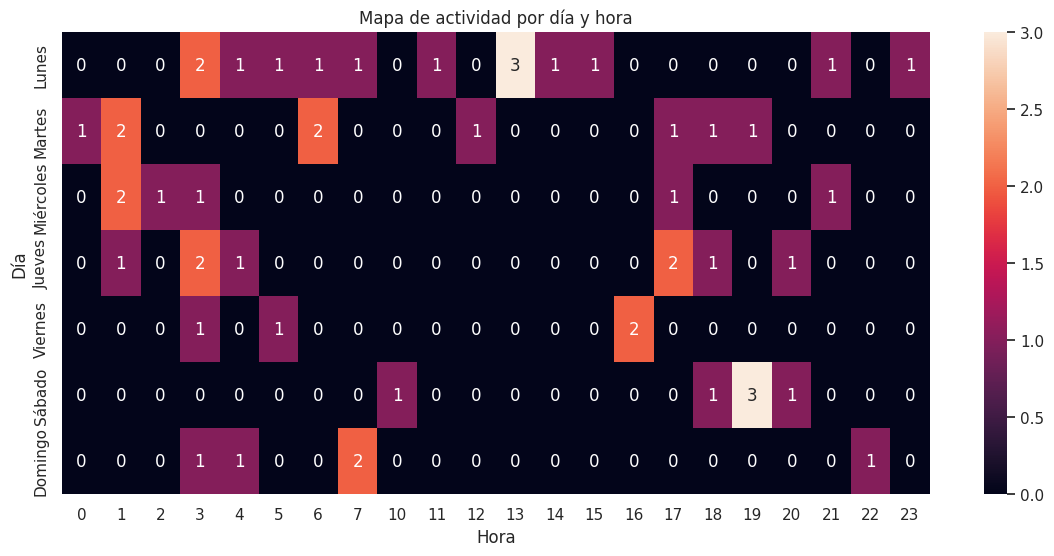

In [59]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    tabla_hora_dia,
    annot=True,
    fmt="d"
)

plt.title("Mapa de actividad por día y hora")
plt.xlabel("Hora")
plt.ylabel("Día")

plt.show()

In [60]:
columnas_numericas = [
    "kills",
    "muertes",
    "asistencias",
    "kda_calculado",
    "cs",
    "cs_min",
    "oro",
    "oro_min",
    "dano_campeones",
    "dano_min",
    "dano_recibido",
    "vision_score",
    "wards_colocados",
    "wards_destruidos",
    "control_wards",
    "kill_participation",
    "duracion_min"
]

correlacion = df[columnas_numericas].corr()

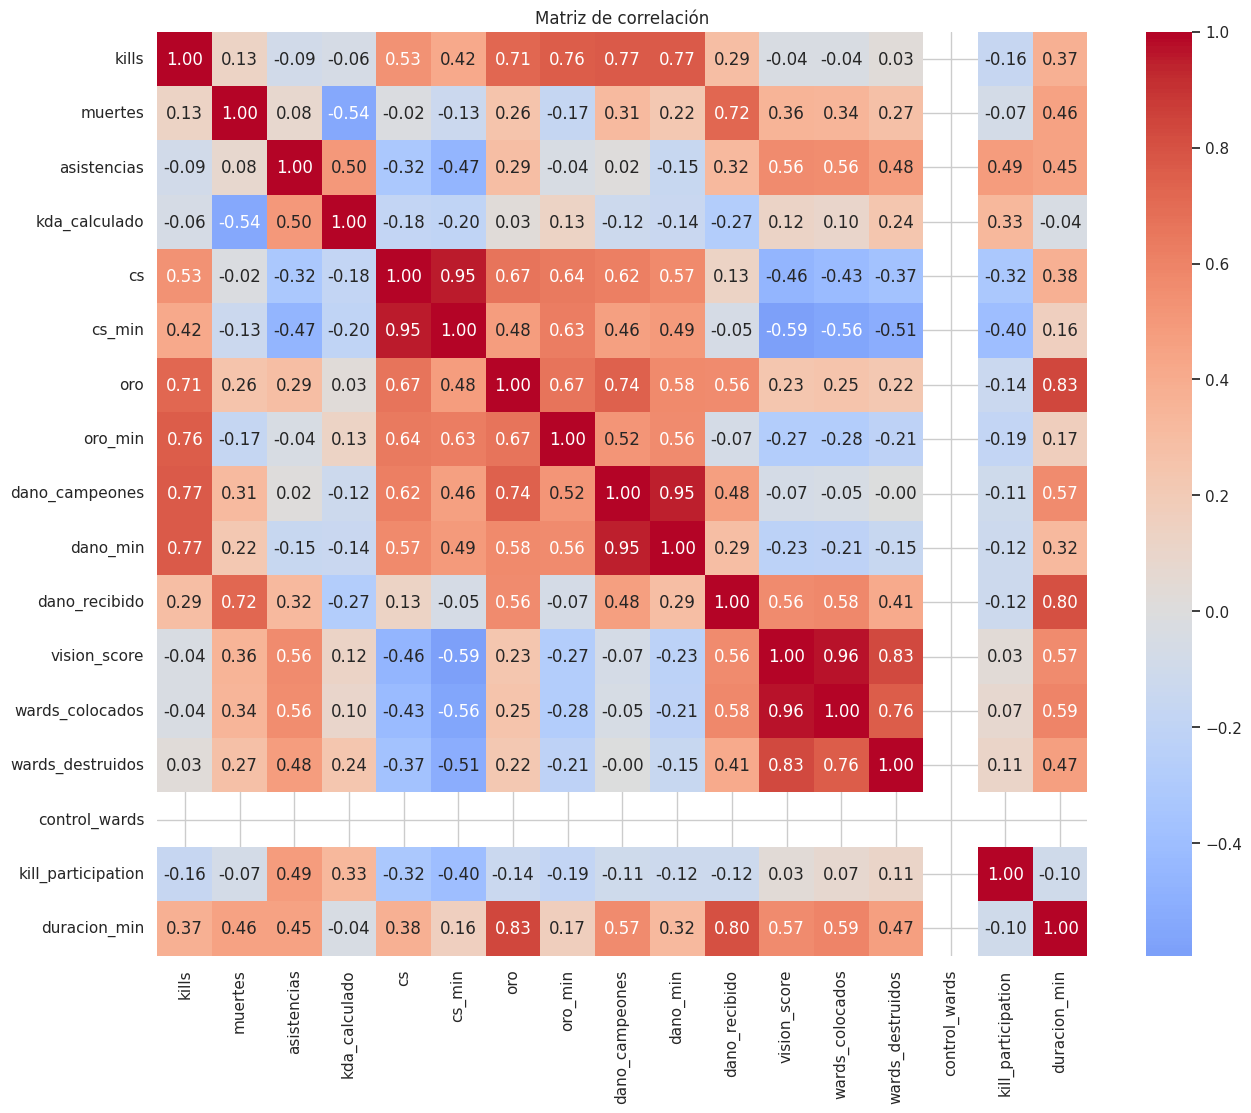

In [61]:
plt.figure(figsize=(15, 12))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación")
plt.show()

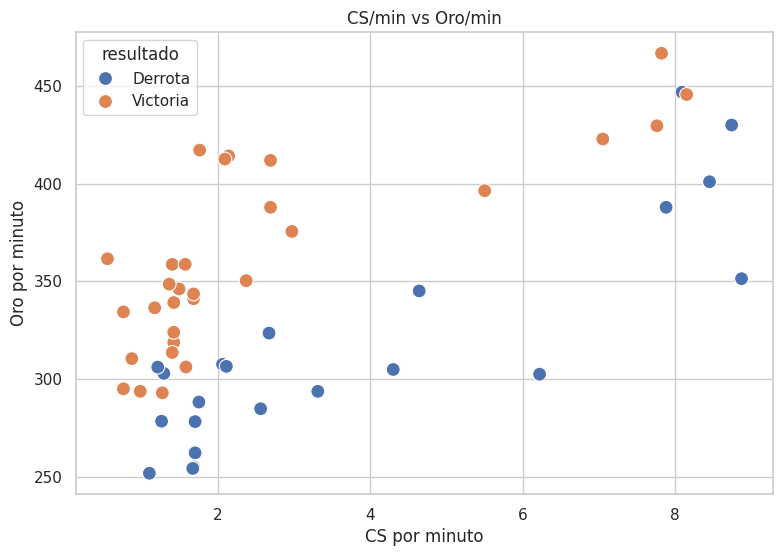

In [63]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="cs_min",
    y="oro_min",
    hue="resultado",
    s=100
)

plt.title("CS/min vs Oro/min")
plt.xlabel("CS por minuto")
plt.ylabel("Oro por minuto")

plt.show()

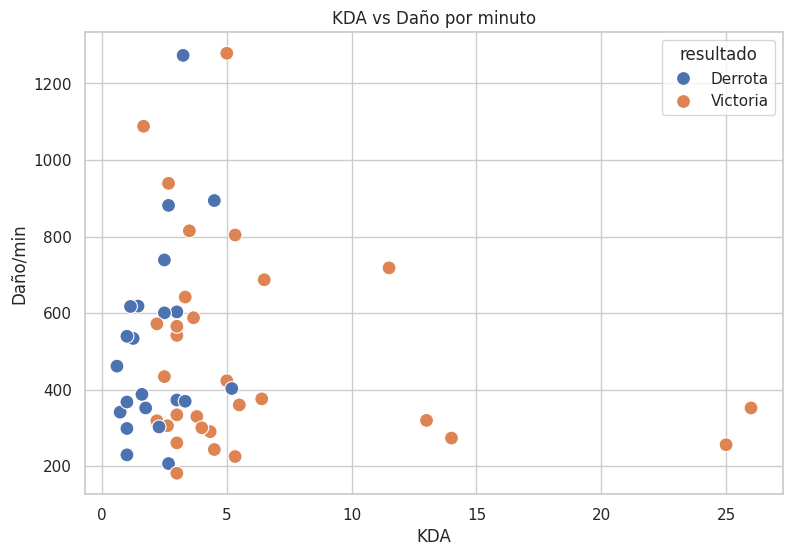

In [64]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="kda_calculado",
    y="dano_min",
    hue="resultado",
    s=100
)

plt.title("KDA vs Daño por minuto")
plt.xlabel("KDA")
plt.ylabel("Daño/min")

plt.show()

In [65]:
resumen = pd.DataFrame({
    "Métrica": [
        "Partidas",
        "Victorias",
        "Derrotas",
        "Win Rate",
        "KDA promedio",
        "Kills promedio",
        "Muertes promedio",
        "Asistencias promedio",
        "CS/min promedio",
        "Oro/min promedio",
        "Daño/min promedio",
        "Kill Participation promedio",
        "Vision Score promedio",
        "Duración promedio"
    ],

    "Valor": [
        len(df),
        victorias,
        derrotas,
        f"{winrate:.2f}%",
        f"{df['kda_calculado'].mean():.2f}",
        f"{df['kills'].mean():.2f}",
        f"{df['muertes'].mean():.2f}",
        f"{df['asistencias'].mean():.2f}",
        f"{df['cs_min'].mean():.2f}",
        f"{df['oro_min'].mean():.2f}",
        f"{df['dano_min'].mean():.2f}",
        f"{df['kill_participation'].mean():.2f}%",
        f"{df['vision_score'].mean():.2f}",
        f"{df['duracion_min'].mean():.2f} min"
    ]
})

display(resumen)

,Métrica,Valor
0,Partidas,52
1,Victorias,30
2,Derrotas,22
3,Win Rate,57.69%
4,KDA promedio,4.46
5,Kills promedio,3.40
6,Muertes promedio,5.19
7,Asistencias promedio,12.56
8,CS/min promedio,3.06
9,Oro/min promedio,342.58


In [66]:
resumen.to_csv(
    "resumen_analisis_lol.csv",
    index=False
)

In [67]:
resumen.to_csv(
    "resumen_analisis_lol.csv",
    index=False
)